# LSTM-GAN - Test
This notebook tests the LSTM-GAN model for data generation and prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Ensure project root is in path
sys.path.append(str(Path.cwd().parent.parent))
from DNN.LSTM_GAN.Model import LSTM_GAN

c:\Users\MHossein\anaconda3\envs\quant-env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Data loaded. Shape: (12287, 24, 19)

--- Training LSTM Predictor ---
Epoch 1/10


c:\Users\MHossein\anaconda3\envs\quant-env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\MHossein\anaconda3\envs\quant-env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\MHossein\anaconda3\envs\quant-env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


154/154 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0110 - val_loss: 1.4831e-04
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 3.0416e-04 - val_loss: 9.5811e-05
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.0198e-04 - val_loss: 7.2989e-05
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.5745e-04 - val_loss: 6.1203e-05
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.3392e-04 - val_loss: 5.9013e-05
Epoch 6/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.2554e-04 - val_loss: 6.8961e-05
Epoch 7/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.1977e-04 - val_loss: 5.8233e-05
Epoch 8/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.1732e-04 - val_loss: 7.3545e-05
Epoch 9/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.1369e-04 - val_loss: 6.9871e-05
Epoch 10/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.1050e-04 - val_loss: 5.8657e-05


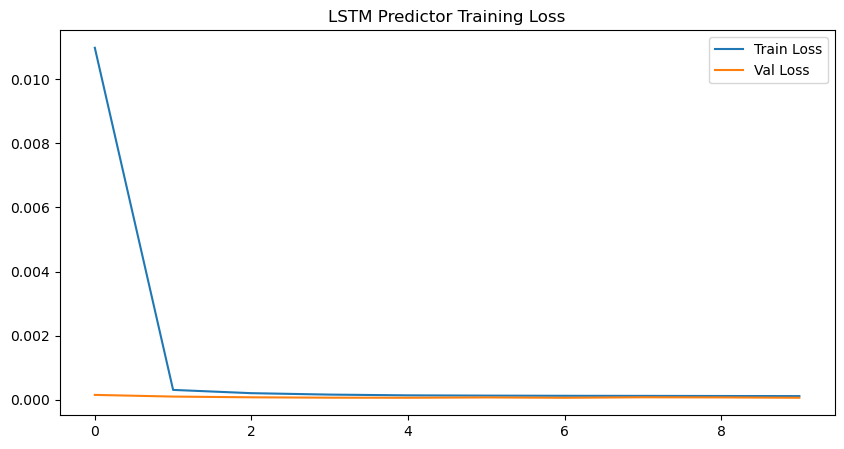

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


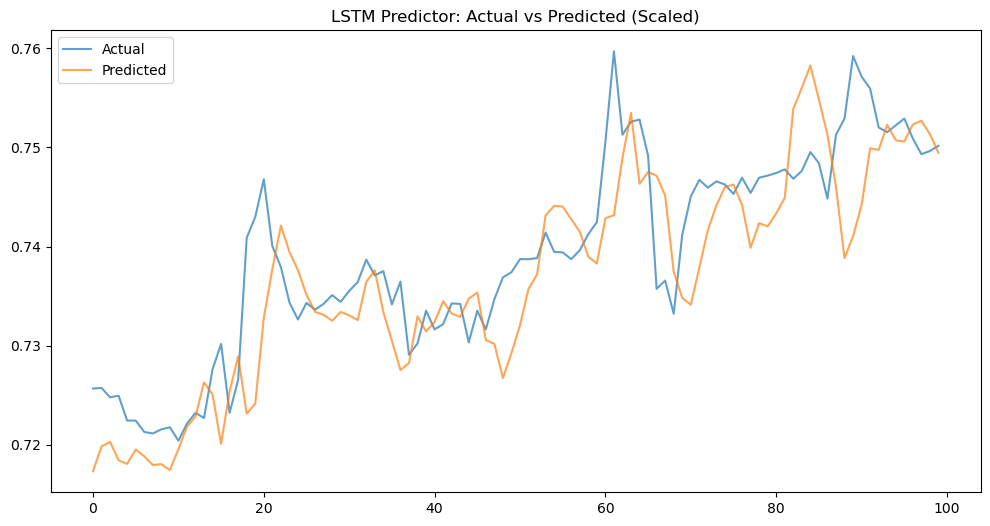


--- Training GAN ---
Epoch 1, D Loss: 0.6124590039253235, G Loss: 0.572910726070404
Epoch 2, D Loss: 0.5187325477600098, G Loss: 0.7610048651695251
Epoch 3, D Loss: 0.4592705965042114, G Loss: 0.933031439781189
Epoch 4, D Loss: 0.4276306927204132, G Loss: 1.0643725395202637
Epoch 5, D Loss: 0.42223504185676575, G Loss: 1.1509908437728882
Epoch 6, D Loss: 0.43235358595848083, G Loss: 1.1918121576309204
Epoch 7, D Loss: 0.4597737789154053, G Loss: 1.1553637981414795
Epoch 8, D Loss: 0.4851302206516266, G Loss: 1.124782919883728
Epoch 9, D Loss: 0.5060145258903503, G Loss: 1.102562427520752
Epoch 10, D Loss: 0.5235928893089294, G Loss: 1.0829099416732788
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


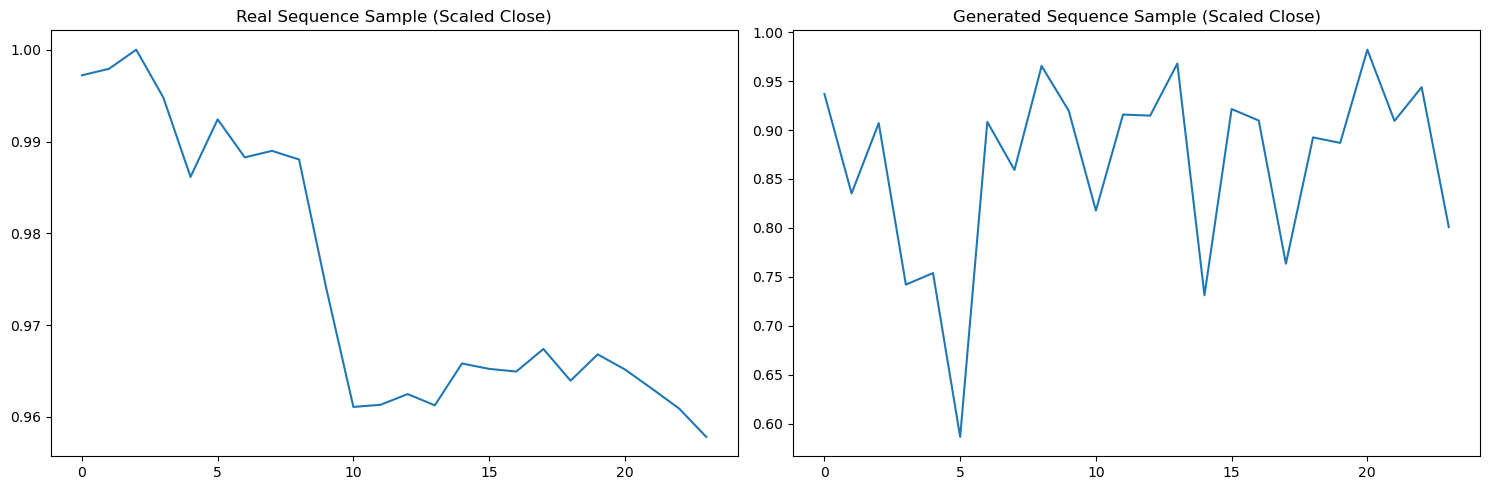

In [2]:
gan = LSTM_GAN()
# Using a smaller default dataset for testing if available, else standard
X, y = gan.load_and_preprocess(filename='GBPUSD_1h.csv')
if X is not None:
    print(f"Data loaded. Shape: {X.shape}")
    
    print("\n--- Training LSTM Predictor ---")
    history = gan.train_lstm(X, y, epochs=10)
    
    # Plot LSTM Training History
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('LSTM Predictor Training Loss')
    plt.legend()
    plt.show()
    
    # LSTM Prediction Visualization
    y_pred = gan.lstm_model.predict(X[-100:])
    plt.figure(figsize=(12, 6))
    plt.plot(y[-100:], label='Actual', alpha=0.7)
    plt.plot(y_pred, label='Predicted', alpha=0.7)
    plt.title('LSTM Predictor: Actual vs Predicted (Scaled)')
    plt.legend()
    plt.show()

    print("\n--- Training GAN ---")
    gan.train_gan(X, epochs=10)
    
    # GAN Synthesis Visualization
    noise = np.random.normal(0, 1, size=[5, gan.latent_dim])
    generated_sequences = gan.generator.predict(noise)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot Real sequence sample
    axes[0].plot(X[0, :, 3]) # Assuming 3 is 'Close'
    axes[0].set_title("Real Sequence Sample (Scaled Close)")
    
    # Plot Generated sequence sample
    axes[1].plot(generated_sequences[0, :, 3])
    axes[1].set_title("Generated Sequence Sample (Scaled Close)")
    
    plt.tight_layout()
    plt.show()